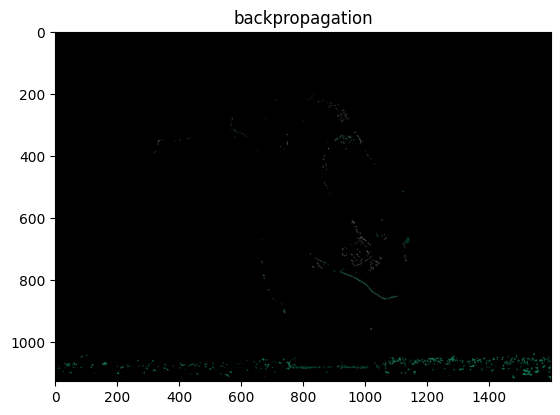

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# roi or region of interest is the object or region tat we need to find
roi = cv2.imread('ground.jpg')
hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)

# target is the image we search in
target = cv2.imread('messi.png')
hsvt = cv2.cvtColor(target, cv2.COLOR_BGR2HSV)

# calculating object histogram
roihist = cv2.calcHist([hsv],[0,1],None,[180, 256],[0, 180, 0, 256])

# Normalizing histogram and applying backpropagation
cv2.normalize(roihist, roihist, 0, 255, cv2.NORM_MINMAX) # MinMax normalization
dst = cv2.calcBackProject([hsvt],[0,1],roihist, [0, 180, 0, 256],1) # In the hist, we need to give hist of roi

# Convoluting with circular disc
disc = cv2.getStructuringElement(cv2.MORPH_DILATE, (5,5))
cv2.filter2D(dst, -1, disc, dst)

ret, thresh = cv2.threshold(dst, 50, 255, 0)
thresh = cv2.merge((thresh, thresh, thresh))
res = cv2.bitwise_and(target,thresh)

plt.imshow(res), plt.title('backpropagation')
plt.show()